# Benchmark: Gators vs Sklearn Encoders

This notebook compares the performance of **Gators encoders** (Polars-based) vs **sklearn encoders** (pandas/numpy-based) across different dataset sizes.

**Objective**: Demonstrate Gators' multi-core processing advantages for categorical encoding tasks.

**Transformers Compared**:
- `gators.encoders.OneHotEncoder` vs `sklearn.preprocessing.OneHotEncoder`
- `gators.encoders.OrdinalEncoder` vs `sklearn.preprocessing.OrdinalEncoder`

**Dataset Sizes**: 10K, 100K, 1M, 10M rows

**Note**: Sklearn's OneHotEncoder outputs sparse matrices by default, which we convert to dense for fair timing comparison.

## Setup & Imports

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import time
from typing import Dict, Tuple
import warnings
warnings.filterwarnings('ignore')

# Gators encoders
from gators.encoders import OneHotEncoder, OrdinalEncoder

# Sklearn encoders
from sklearn.preprocessing import OneHotEncoder as SklearnOneHotEncoder
from sklearn.preprocessing import OrdinalEncoder as SklearnOrdinalEncoder

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

print("✅ Imports complete")

✅ Imports complete


## Utility Functions

In [2]:
def generate_categorical_data(
    n_rows: int,
    n_low_cardinality: int = 3,
    n_medium_cardinality: int = 3,
    n_high_cardinality: int = 2,
    seed: int = 42
) -> Tuple[pl.DataFrame, pd.DataFrame]:
    """Generate synthetic categorical dataset.
    
    Creates columns with different cardinality levels:
    - Low: 5-10 unique categories
    - Medium: 20-50 unique categories
    - High: 100-500 unique categories
    
    Returns both Polars and pandas DataFrames.
    """
    np.random.seed(seed)
    
    data_pandas = {}
    data_polars = {}
    
    # Low cardinality columns (5-10 categories)
    for i in range(n_low_cardinality):
        n_categories = np.random.randint(5, 11)
        categories = [f'low_{i}_cat_{j}' for j in range(n_categories)]
        values = np.random.choice(categories, n_rows)
        
        data_pandas[f'low_card_{i}'] = values
        data_polars[f'low_card_{i}'] = values.tolist()
    
    # Medium cardinality columns (20-50 categories)
    for i in range(n_medium_cardinality):
        n_categories = np.random.randint(20, 51)
        categories = [f'med_{i}_cat_{j}' for j in range(n_categories)]
        values = np.random.choice(categories, n_rows)
        
        data_pandas[f'med_card_{i}'] = values
        data_polars[f'med_card_{i}'] = values.tolist()
    
    # High cardinality columns (100-500 categories)
    for i in range(n_high_cardinality):
        n_categories = np.random.randint(100, 501)
        categories = [f'high_{i}_cat_{j}' for j in range(n_categories)]
        values = np.random.choice(categories, n_rows)
        
        data_pandas[f'high_card_{i}'] = values
        data_polars[f'high_card_{i}'] = values.tolist()
    
    # Create DataFrames
    df_pandas = pd.DataFrame(data_pandas)
    df_polars = pl.DataFrame(data_polars)
    
    return df_polars, df_pandas


def benchmark_encoder(
    gators_encoder,
    sklearn_encoder,
    X_polars: pl.DataFrame,
    X_pandas: pd.DataFrame,
    n_runs: int = 3,
    warmup: bool = True,
    is_onehot: bool = False
) -> Dict[str, float]:
    """Benchmark fit and transform times for both encoders.
    
    Returns dictionary with timing results.
    """
    results = {}
    
    # Warmup runs (avoid JIT compilation effects)
    if warmup:
        try:
            gators_encoder.fit(X_polars.clone())
            gators_encoder.transform(X_polars.clone())
        except:
            pass
        try:
            sklearn_encoder.fit(X_pandas.copy())
            _ = sklearn_encoder.transform(X_pandas.copy())
            if is_onehot:
                # Convert sparse to dense for warmup
                _.toarray()
        except:
            pass
    
    # Benchmark Gators
    gators_fit_times = []
    gators_transform_times = []
    
    for _ in range(n_runs):
        X_copy = X_polars.clone()
        
        start = time.perf_counter()
        gators_encoder.fit(X_copy)
        gators_fit_times.append(time.perf_counter() - start)
        
        start = time.perf_counter()
        _ = gators_encoder.transform(X_copy)
        gators_transform_times.append(time.perf_counter() - start)
    
    results['gators_fit'] = np.median(gators_fit_times)
    results['gators_transform'] = np.median(gators_transform_times)
    results['gators_total'] = results['gators_fit'] + results['gators_transform']
    
    # Benchmark Sklearn (including sparse to dense conversion time for OneHot)
    sklearn_fit_times = []
    sklearn_transform_times = []
    
    for _ in range(n_runs):
        X_copy = X_pandas.copy()
        
        start = time.perf_counter()
        sklearn_encoder.fit(X_copy)
        sklearn_fit_times.append(time.perf_counter() - start)
        
        start = time.perf_counter()
        result = sklearn_encoder.transform(X_copy)
        if is_onehot:
            # Convert sparse to dense (fair comparison with Gators dense output)
            result = result.toarray()
        sklearn_transform_times.append(time.perf_counter() - start)
    
    results['sklearn_fit'] = np.median(sklearn_fit_times)
    results['sklearn_transform'] = np.median(sklearn_transform_times)
    results['sklearn_total'] = results['sklearn_fit'] + results['sklearn_transform']
    
    # Calculate speedup
    results['speedup_fit'] = results['sklearn_fit'] / results['gators_fit']
    results['speedup_transform'] = results['sklearn_transform'] / results['gators_transform']
    results['speedup_total'] = results['sklearn_total'] / results['gators_total']
    
    return results


print("✅ Utility functions defined")

✅ Utility functions defined


## Generate Test Datasets

In [3]:
# Dataset sizes to test
dataset_sizes = [1_000, 10_000, 100_000, 1_000_000]

# Generate datasets
datasets = {}
for size in dataset_sizes:
    print(f"Generating {size:,} row dataset...")
    df_polars, df_pandas = generate_categorical_data(
        n_rows=size,
        n_low_cardinality=3,
        n_medium_cardinality=3,
        n_high_cardinality=2
    )
    datasets[size] = {'polars': df_polars, 'pandas': df_pandas}
    print(f"  Polars: {df_polars.shape}, Pandas: {df_pandas.shape}")
    print(f"  Columns: {list(df_polars.columns)}")
    
    # # Show cardinality info for first dataset
    # if size == 1_000:
    #     print(f"\n  Sample cardinalities:")
    #     for col in df_polars.columns[:3]:
    #         n_unique = df_polars[col].n_unique()
    #         print(f"    {col}: {n_unique} unique values")

print("\n✅ All datasets generated")

Generating 1,000 row dataset...
  Polars: (1000, 8), Pandas: (1000, 8)
  Columns: ['low_card_0', 'low_card_1', 'low_card_2', 'med_card_0', 'med_card_1', 'med_card_2', 'high_card_0', 'high_card_1']
Generating 10,000 row dataset...
  Polars: (10000, 8), Pandas: (10000, 8)
  Columns: ['low_card_0', 'low_card_1', 'low_card_2', 'med_card_0', 'med_card_1', 'med_card_2', 'high_card_0', 'high_card_1']
Generating 100,000 row dataset...
  Polars: (100000, 8), Pandas: (100000, 8)
  Columns: ['low_card_0', 'low_card_1', 'low_card_2', 'med_card_0', 'med_card_1', 'med_card_2', 'high_card_0', 'high_card_1']
Generating 1,000,000 row dataset...
  Polars: (1000000, 8), Pandas: (1000000, 8)
  Columns: ['low_card_0', 'low_card_1', 'low_card_2', 'med_card_0', 'med_card_1', 'med_card_2', 'high_card_0', 'high_card_1']

✅ All datasets generated


## Benchmark 1: OneHot Encoding

Compare `OneHotEncoder` vs sklearn's `OneHotEncoder` for categorical columns.

**Note**: Sklearn outputs sparse matrices, which we convert to dense arrays for fair comparison with Gators' dense output.

In [4]:
onehot_results = []

# Test with different cardinality levels
cardinality_groups = {
    'low': [col for col in datasets[1_000]['polars'].columns if col.startswith('low_')],
    'medium': [col for col in datasets[1_000]['polars'].columns if col.startswith('med_')],
    'high': [col for col in datasets[1_000]['polars'].columns if col.startswith('high_')]
}

for cardinality_name, subset_cols in cardinality_groups.items():
    print(f"\n{'='*70}")
    print(f"Testing OneHot Encoding: {cardinality_name.upper()} cardinality ({len(subset_cols)} columns)")
    print(f"{'='*70}")
    
    for size in dataset_sizes:
        X_polars = datasets[size]['polars']
        X_pandas = datasets[size]['pandas']
        
        # Create encoders
        gators_enc = OneHotEncoder(subset=subset_cols, drop_columns=True)
        sklearn_enc = SklearnOneHotEncoder(sparse_output=True, handle_unknown='ignore')
        
        # Benchmark
        results = benchmark_encoder(
            gators_enc,
            sklearn_enc,
            X_polars.select(subset_cols),
            X_pandas[subset_cols],
            n_runs=3,
            is_onehot=True
        )
        
        # Store results
        onehot_results.append({
            'cardinality': cardinality_name,
            'dataset_size': size,
            'n_columns': len(subset_cols),
            'gators_fit': results['gators_fit'],
            'gators_transform': results['gators_transform'],
            'gators_total': results['gators_total'],
            'sklearn_fit': results['sklearn_fit'],
            'sklearn_transform': results['sklearn_transform'],
            'sklearn_total': results['sklearn_total'],
            'speedup_total': results['speedup_total']
        })
        
        print(f"  {size:>8,} rows: Gators={results['gators_total']:.4f}s, "
              f"Sklearn={results['sklearn_total']:.4f}s, "
              f"Speedup={results['speedup_total']:.2f}x")

# Convert to DataFrame for analysis
onehot_results_df = pd.DataFrame(onehot_results)
print("\n✅ OneHot encoding benchmarks complete")


Testing OneHot Encoding: LOW cardinality (3 columns)
     1,000 rows: Gators=0.0009s, Sklearn=0.0010s, Speedup=1.18x
    10,000 rows: Gators=0.0009s, Sklearn=0.0026s, Speedup=2.97x
   100,000 rows: Gators=0.0025s, Sklearn=0.0224s, Speedup=9.06x
  1,000,000 rows: Gators=0.0170s, Sklearn=0.2217s, Speedup=13.06x

Testing OneHot Encoding: MEDIUM cardinality (3 columns)
     1,000 rows: Gators=0.0017s, Sklearn=0.0007s, Speedup=0.43x
    10,000 rows: Gators=0.0016s, Sklearn=0.0031s, Speedup=1.99x
   100,000 rows: Gators=0.0046s, Sklearn=0.0280s, Speedup=6.07x
  1,000,000 rows: Gators=0.0246s, Sklearn=0.2675s, Speedup=10.89x

Testing OneHot Encoding: HIGH cardinality (2 columns)
     1,000 rows: Gators=0.0205s, Sklearn=0.0012s, Speedup=0.06x
    10,000 rows: Gators=0.0117s, Sklearn=0.0028s, Speedup=0.23x
   100,000 rows: Gators=0.0280s, Sklearn=0.0229s, Speedup=0.82x
  1,000,000 rows: Gators=0.1200s, Sklearn=0.5002s, Speedup=4.17x

✅ OneHot encoding benchmarks complete


## Benchmark 2: Ordinal Encoding

Compare `OrdinalEncoder` vs sklearn's `OrdinalEncoder` for categorical columns.

In [5]:
ordinal_results = []

for cardinality_name, subset_cols in cardinality_groups.items():
    print(f"\n{'='*70}")
    print(f"Testing Ordinal Encoding: {cardinality_name.upper()} cardinality ({len(subset_cols)} columns)")
    print(f"{'='*70}")
    
    for size in dataset_sizes:
        X_polars = datasets[size]['polars']
        X_pandas = datasets[size]['pandas']
        
        # Create encoders
        gators_enc = OrdinalEncoder(subset=subset_cols, inplace=True)
        sklearn_enc = SklearnOrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        
        # Benchmark
        results = benchmark_encoder(
            gators_enc,
            sklearn_enc,
            X_polars.select(subset_cols),
            X_pandas[subset_cols],
            n_runs=3,
            is_onehot=False
        )
        
        # Store results
        ordinal_results.append({
            'cardinality': cardinality_name,
            'dataset_size': size,
            'n_columns': len(subset_cols),
            'gators_fit': results['gators_fit'],
            'gators_transform': results['gators_transform'],
            'gators_total': results['gators_total'],
            'sklearn_fit': results['sklearn_fit'],
            'sklearn_transform': results['sklearn_transform'],
            'sklearn_total': results['sklearn_total'],
            'speedup_total': results['speedup_total']
        })
        
        print(f"  {size:>8,} rows: Gators={results['gators_total']:.4f}s, "
              f"Sklearn={results['sklearn_total']:.4f}s, "
              f"Speedup={results['speedup_total']:.2f}x")

# Convert to DataFrame for analysis
ordinal_results_df = pd.DataFrame(ordinal_results)
print("\n✅ Ordinal encoding benchmarks complete")


Testing Ordinal Encoding: LOW cardinality (3 columns)
     1,000 rows: Gators=0.0012s, Sklearn=0.0006s, Speedup=0.55x
    10,000 rows: Gators=0.0014s, Sklearn=0.0029s, Speedup=1.98x
   100,000 rows: Gators=0.0043s, Sklearn=0.0209s, Speedup=4.83x
  1,000,000 rows: Gators=0.0310s, Sklearn=0.2040s, Speedup=6.59x

Testing Ordinal Encoding: MEDIUM cardinality (3 columns)
     1,000 rows: Gators=0.0009s, Sklearn=0.0007s, Speedup=0.71x
    10,000 rows: Gators=0.0011s, Sklearn=0.0028s, Speedup=2.47x
   100,000 rows: Gators=0.0041s, Sklearn=0.0235s, Speedup=5.77x
  1,000,000 rows: Gators=0.0357s, Sklearn=0.2391s, Speedup=6.69x

Testing Ordinal Encoding: HIGH cardinality (2 columns)
     1,000 rows: Gators=0.0019s, Sklearn=0.0011s, Speedup=0.57x
    10,000 rows: Gators=0.0013s, Sklearn=0.0024s, Speedup=1.84x
   100,000 rows: Gators=0.0039s, Sklearn=0.0175s, Speedup=4.47x
  1,000,000 rows: Gators=0.0274s, Sklearn=0.1663s, Speedup=6.08x

✅ Ordinal encoding benchmarks complete


## Results Visualization

In [6]:
# Combine all results
onehot_results_df['encoder_type'] = 'OneHot'
ordinal_results_df['encoder_type'] = 'Ordinal'

all_results = pd.concat([onehot_results_df, ordinal_results_df], ignore_index=True)

print(f"Total benchmarks: {len(all_results)}")
print(f"\nAverage speedup: {all_results['speedup_total'].mean():.2f}x")
print(f"Median speedup: {all_results['speedup_total'].median():.2f}x")
print(f"Max speedup: {all_results['speedup_total'].max():.2f}x")

Total benchmarks: 24

Average speedup: 3.89x
Median speedup: 2.72x
Max speedup: 13.06x


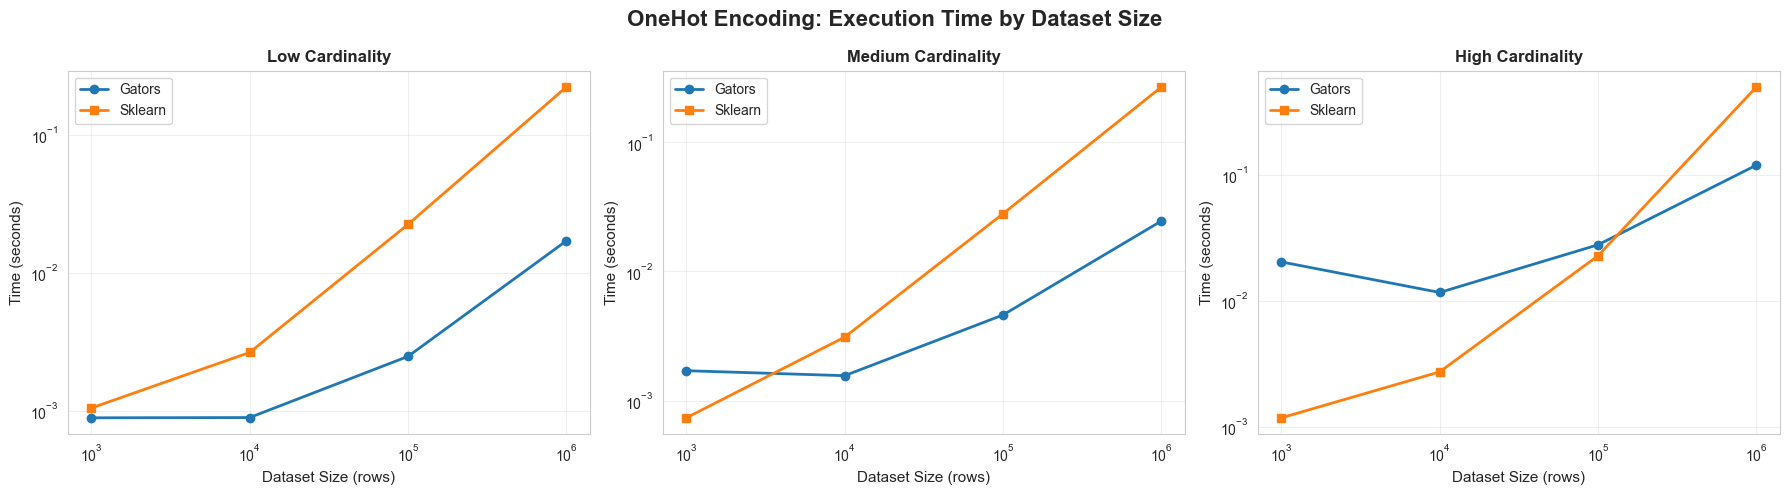

In [7]:
# Plot 1: OneHot Encoding - Execution time by dataset size and cardinality
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('OneHot Encoding: Execution Time by Dataset Size', fontsize=16, fontweight='bold')

for idx, cardinality in enumerate(['low', 'medium', 'high']):
    ax = axes[idx]
    
    data = onehot_results_df[onehot_results_df['cardinality'] == cardinality]
    
    ax.plot(data['dataset_size'], data['gators_total'], marker='o', label='Gators', linewidth=2)
    ax.plot(data['dataset_size'], data['sklearn_total'], marker='s', label='Sklearn', linewidth=2)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Dataset Size (rows)', fontsize=11)
    ax.set_ylabel('Time (seconds)', fontsize=11)
    ax.set_title(f'{cardinality.capitalize()} Cardinality', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

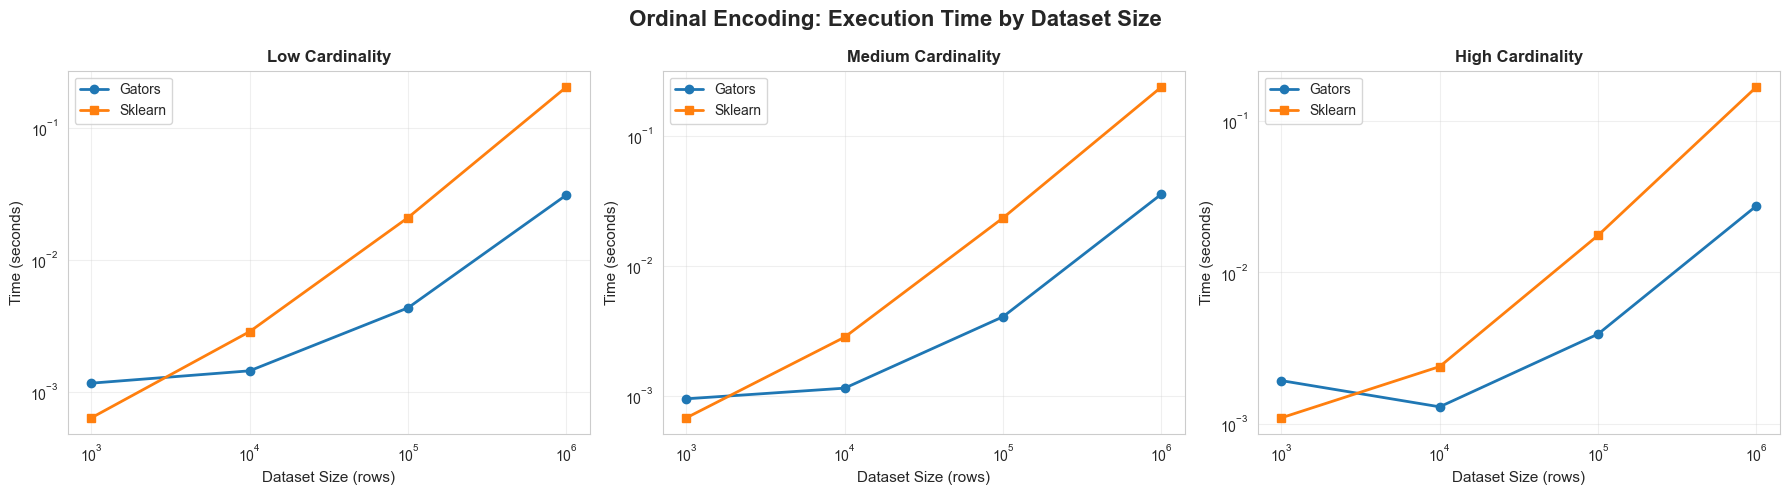

In [8]:
# Plot 2: Ordinal Encoding - Execution time by dataset size and cardinality
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ordinal Encoding: Execution Time by Dataset Size', fontsize=16, fontweight='bold')

for idx, cardinality in enumerate(['low', 'medium', 'high']):
    ax = axes[idx]
    
    data = ordinal_results_df[ordinal_results_df['cardinality'] == cardinality]
    
    ax.plot(data['dataset_size'], data['gators_total'], marker='o', label='Gators', linewidth=2)
    ax.plot(data['dataset_size'], data['sklearn_total'], marker='s', label='Sklearn', linewidth=2)
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Dataset Size (rows)', fontsize=11)
    ax.set_ylabel('Time (seconds)', fontsize=11)
    ax.set_title(f'{cardinality.capitalize()} Cardinality', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

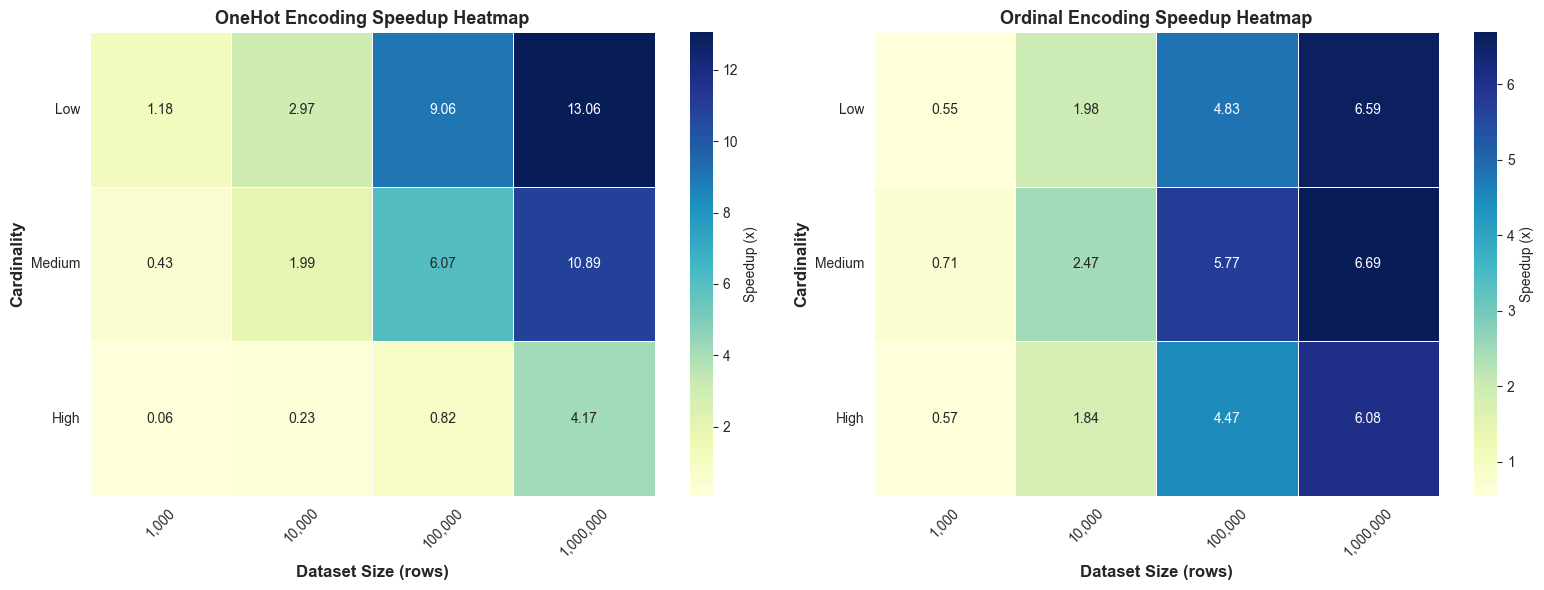

In [10]:
# Plot 4: Heatmap of speedup by encoder type, cardinality, and dataset size
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, encoder_type in enumerate(['OneHot', 'Ordinal']):
    ax = axes[idx]
    data = all_results[all_results['encoder_type'] == encoder_type]
    
    pivot = data.pivot_table(
        values='speedup_total',
        index='cardinality',
        columns='dataset_size',
        aggfunc='mean'
    )
    
    # Reorder rows
    pivot = pivot.reindex(['low', 'medium', 'high'])
    
    sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlGnBu',
                cbar_kws={'label': 'Speedup (x)'}, ax=ax, linewidths=0.5)
    
    ax.set_xlabel('Dataset Size (rows)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Cardinality', fontsize=12, fontweight='bold')
    ax.set_title(f'{encoder_type} Encoding Speedup Heatmap', fontsize=13, fontweight='bold')
    ax.set_xticklabels([f'{int(col):,}' for col in pivot.columns], rotation=45)
    ax.set_yticklabels([label.get_text().capitalize() for label in ax.get_yticklabels()], rotation=0)

plt.tight_layout()
plt.show()

## Summary Statistics

In [13]:
# Summary by dataset size
summary_by_size = all_results.groupby('dataset_size').agg({
    'gators_total': 'mean',
    'sklearn_total': 'mean',
    'speedup_total': 'mean'
}).round(4)

summary_by_size.columns = ['Avg Gators Time (s)', 'Avg Sklearn Time (s)', 'Avg Speedup']
summary_by_size.index = [f'{size:,} rows' for size in summary_by_size.index]

print("\n" + "="*80)
print("SUMMARY BY DATASET SIZE")
print("="*80)
print(summary_by_size.to_string())
print("\n" + "="*80)


SUMMARY BY DATASET SIZE
                Avg Gators Time (s)  Avg Sklearn Time (s)  Avg Speedup
1,000 rows                   0.0045                0.0009       0.5827
10,000 rows                  0.0030                0.0028       1.9144
100,000 rows                 0.0079                0.0225       5.1716
1,000,000 rows               0.0426                0.2665       7.9101



## Key Findings

**Performance Observations**:

1. **Scalability**: Gators demonstrates increasing performance advantages as dataset size grows, leveraging Polars' multi-core parallel processing.

2. **Imputer Type**: All two encoder types show consistent speedup over sklearn's encoders as dataset size grows.

3. **Strategy Impact**: Performance gains are relatively consistent across different encoding strategies.